# Comparison of methods
Having gone through GAN variations and Diffusion variations, it's worth seeing how these perform all in comparison to each other. We eliminate some methods that we saw just gave poor results on our set and focus on the following:
- Conditional GAN
- Conditional GAN with feature matching
- Conditional GAN with feature matching and entropy
- Diffusion
- Conditional Diffusion

Note : We exclude Vanilla GAN, Vanilla WGAN-GP, and Conditional WGAN-GP because they gave poor results that aren't even close.

In [1]:
import copy
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import Generator, Discriminator
from synthetic_generation.diffusion.models import DiffusionNet
from synthetic_generation.diffusion.process import DiffusionProcess
from synthetic_generation.diffusion.schedules import linear_beta_schedule
from synthetic_generation.gan.process import GANProcess

### First we create the data

In [2]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create distribution of disk-like clusters centered at the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be created
    centers : int   
        number of clusters to have
    radius : float
        distance to origin of cluster centers
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    tuple(np.ndarray)
        array of points, array of centers for each point, array of labels for each point
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:

# Create data and labels and points
X, c_label, c_center = make_gaussian_mixture()

In [4]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

In [5]:
# combine the centers and labels into one conditional vector
c = torch.cat([torch.tensor(c_center), one_hot], dim=1)

In [6]:
# seed for reproducibility of weights
torch.manual_seed(42)

For this comparison, unlike the previous examples, we will make a test-train split where we train on a portion of data, and create output from the models and compare that to the test data. This allows us to potentially create a baseline ground truth, i.e. we can see how that held out test data compares as "generated" data compared to model generated data. 

In [7]:
# combine the data and conditionals into a Dataset
dataset = TensorDataset(torch.Tensor(X).float(),c)
# Define the split ratio
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoader for each dataset
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

In [8]:
# now we want to combine the test data into just one X_test, c_test
test_data = []
test_conditional = []
for batch in test_loader:
    test_data.append(batch[0])
    test_conditional.append(batch[1])

X_test = torch.cat(test_data)
c_test = torch.cat(test_conditional)

### Creating the GAN models to use

We make three identical Generator/Discriminator pairs and use GAN process training with each pair for the three GAN variations

In [10]:
# set seed again
torch.manual_seed(42)

In [11]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

G_fm = copy.deepcopy(G)
G_fm_e = copy.deepcopy(G)

In [12]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

D_fm = copy.deepcopy(D)
D_fm_e = copy.deepcopy(D)

In [13]:
# train conditional GAN with no regularization
# create a process
process = GANProcess(G=G, D=D)
torch.manual_seed(42) # seed again
process.train(
    X=train_loader
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [14]:
# train with just feature matching
torch.manual_seed(42) # seed again
process_fm = GANProcess(G=G_fm, D=D_fm)
process_fm.train(
    X=train_loader,
    lambda_fm_1=0.02,
    lambda_fm_2=0.02,
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
# train with feature matching and entropy
torch.manual_seed(42) # seed again
process_fm_e = GANProcess(G=G_fm_e, D=D_fm_e)
process_fm_e.train(
    X=train_loader,
    lambda_fm_1=0.02,
    lambda_fm_2=0.02,
    lambda_entropy=0.001,
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

### Diffusion models
We now make a vanilla diffusion model and a conditional diffusion model and train those on the same data

In [17]:
torch.manual_seed(42)
# create the model for vanilla diffusion
DenoiseNet = DiffusionNet(data_dim=2, num_hidden_layers=4,  hidden_dims=(256,256))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet.to(device)
# create the one for the conditional
DenoiseNet_conditional = DiffusionNet(data_dim=2, conditional_dim=10, num_hidden_layers=4,  hidden_dims=(256,256))
model_conditional = DenoiseNet_conditional.to(device)

In [41]:
# create the processes for diffusion
diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

diffusion_process_conditional = DiffusionProcess(
    model = model_conditional,
    num_timesteps = model_conditional.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model_conditional.time_embedding.num_timesteps)
)

In [38]:
# extract the datapoints in the train/test split without the conditionals included
uncond_train_data = torch.concat([data[0].unsqueeze(0) for data in train_dataset])
uncond_test_data = torch.concat([data[0].unsqueeze(0) for data in test_dataset])


In [40]:
# turn the train data into a loader
uncond_train_dataset = TensorDataset(uncond_train_data)
uncond_loader = DataLoader(uncond_train_dataset, batch_size=128, shuffle=True)

In [42]:
# train the vanilla diffusion
diffusion_process.train(X=uncond_loader)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
# train the conditional diffusion
diffusion_process_conditional.train(X=train_loader)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

## Creating samples
For each model, we create a sample of 10000 points. For any conditional model we use `c_test` as the conditional so we can compare to the test data

In [57]:
gan_samples = process.generate_samples(num_samples=10000, c=c_test)

In [59]:
gan_samples_fm = process_fm.generate_samples(num_samples=10000, c=c_test)

In [60]:
gan_samples_fm_e = process_fm_e.generate_samples(num_samples=10000, c=c_test)

In [61]:
diff_samples = diffusion_process.generate_samples(num_samples=10000)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

In [62]:
diff_cond_samples = diffusion_process_conditional.generate_samples(num_samples=10000, c=c_test)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

## Visualization
We plot both the X_test true data set and the samples generated from each model (using the conditional that matches X_test for conditional models)

In [63]:
# for plotting we create labels for each possible conditional in the test conditional
labels = c_test[:,2:].argmax(dim=1).numpy()

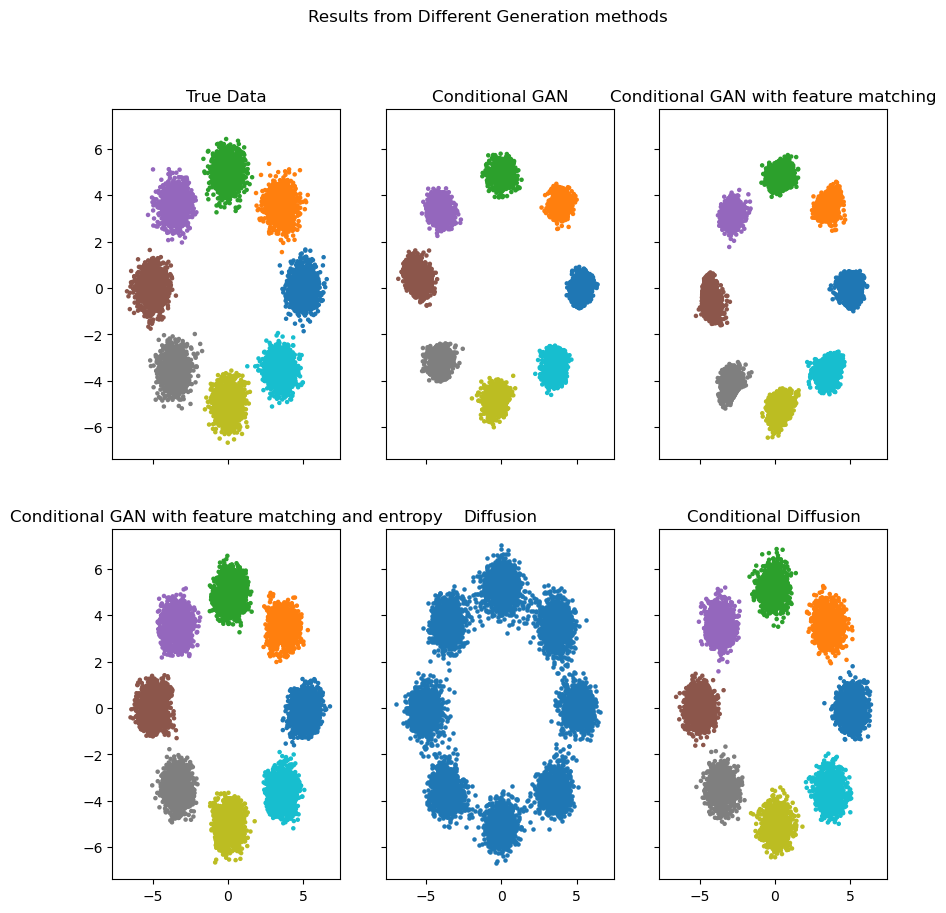

In [80]:
fig, axs = plt.subplots(2, 3, figsize=(10, 10), sharex=True, sharey=True)
axs[0, 0].scatter(X_test[:, 0], X_test[:, 1], c=labels, s=5, cmap="tab10")
axs[0, 0].set_title("True Data")
axs[0, 1].scatter(gan_samples[:,0],gan_samples[:,1],c=labels, s=5, cmap="tab10")
axs[0, 1].set_title("Conditional GAN") 
axs[0, 2].scatter(gan_samples_fm[:, 0], gan_samples_fm[:, 1], c=labels, s=5, cmap="tab10")
axs[0, 2].set_title("Conditional GAN with feature matching")
axs[1, 0].scatter(gan_samples_fm_e[:, 0], gan_samples_fm_e[:, 1], c=labels, s=5, cmap="tab10")
axs[1, 0].set_title("Conditional GAN with feature matching and entropy")
axs[1, 1].scatter(diff_samples[:, 0], diff_samples[:, 1], s=5)
axs[1, 1].set_title("Diffusion")
axs[1, 2].scatter(diff_cond_samples[:, 0], diff_cond_samples[:, 1], s=5, c=labels, cmap="tab10")
axs[1, 2].set_title("Conditional Diffusion")
fig.suptitle("Results from Different Generation methods")
plt.show()

## Looking at some metrics for how good the models are
We want to look at different metrics to measure the model performance of each model. It's worth noting that visually it looks like conditional diffusion is probably the best, but appears to be close behind vanilla diffusion and conditional GAN with feature matching and entropy. To start we use kNN (we'll use `k=5` for these) to compare X_test with each of the generated samples.

In [81]:


def knn_two_sample_test(x_true: torch.Tensor,
                        x_gen: torch.Tensor,
                        k: int = 5,
                        return_details: bool = False):
    """
    kNN two-sample test (leave-one-out).
    
    Args:
        x_true: Tensor [N, D]
        x_gen:  Tensor [M, D]
        k: number of neighbors
        return_details: whether to return class-wise accuracy
        
    Returns:
        accuracy (float)
        optionally dict with detailed metrics
    """

    assert x_true.dim() == 2 and x_gen.dim() == 2
    assert x_true.size(1) == x_gen.size(1)

    device = x_true.device
    
    N = x_true.size(0)
    M = x_gen.size(0)

    # Combine
    X = torch.cat([x_true, x_gen], dim=0)  # [N+M, D]

    # Labels: 0 = real, 1 = generated
    y = torch.cat([
        torch.zeros(N, device=device),
        torch.ones(M, device=device)
    ])

    # Compute pairwise squared distances
    # (x - y)^2 = x^2 + y^2 - 2xy
    XX = (X ** 2).sum(dim=1, keepdim=True)
    dist = XX + XX.T - 2 * X @ X.T

    # Remove self-distance by setting diagonal to large value
    dist.fill_diagonal_(float('inf'))

    # Get k nearest neighbors
    knn_idx = dist.topk(k, largest=False).indices  # [N+M, k]

    # Get neighbor labels
    knn_labels = y[knn_idx]  # [N+M, k]

    # Majority vote
    pred = (knn_labels.mean(dim=1) > 0.5).float()

    # Accuracy
    acc = (pred == y).float().mean().item()

    if not return_details:
        return acc

    # Class-wise accuracy
    real_acc = (pred[:N] == 0).float().mean().item()
    gen_acc = (pred[N:] == 1).float().mean().item()

    return acc, {
        "overall_accuracy": acc,
        "real_accuracy": real_acc,
        "generated_accuracy": gen_acc,
        "deviation_from_0.5": abs(acc - 0.5)
    }


In [88]:
# first the conditional GAN
knn_two_sample_test(X_test, gan_samples, return_details=True)

(0.6855999827384949,
 {'overall_accuracy': 0.6855999827384949,
  'real_accuracy': 0.656499981880188,
  'generated_accuracy': 0.7146999835968018,
  'deviation_from_0.5': 0.18559998273849487})

In [89]:
# next we look at Conditional gan plus feature matching
knn_two_sample_test(X_test, gan_samples_fm, return_details=True)


(0.703000009059906,
 {'overall_accuracy': 0.703000009059906,
  'real_accuracy': 0.6617000102996826,
  'generated_accuracy': 0.7443000078201294,
  'deviation_from_0.5': 0.203000009059906})

In [90]:
# next we look at conditional GAN + feature matching + entropy
knn_two_sample_test(X_test, gan_samples_fm_e, return_details=True)

(0.5123500227928162,
 {'overall_accuracy': 0.5123500227928162,
  'real_accuracy': 0.5063999891281128,
  'generated_accuracy': 0.5182999968528748,
  'deviation_from_0.5': 0.012350022792816162})

In [91]:
# next, we look at vanilla diffusion
knn_two_sample_test(X_test, diff_samples, return_details=True)

(0.5202500224113464,
 {'overall_accuracy': 0.5202500224113464,
  'real_accuracy': 0.5206000208854675,
  'generated_accuracy': 0.5199000239372253,
  'deviation_from_0.5': 0.020250022411346436})

In [92]:
# Finally we consider conditional diffusion
knn_two_sample_test(X_test, diff_cond_samples, return_details=True)

(0.5070499777793884,
 {'overall_accuracy': 0.5070499777793884,
  'real_accuracy': 0.5055000185966492,
  'generated_accuracy': 0.5085999965667725,
  'deviation_from_0.5': 0.007049977779388428})

We can see a few things here. As we saw visually the top 3 are the two diffusion models and the conditional GAN + feature matching + entropy. The other 2 are not very good as a simple kNN can achieve 69-70 percent accuracy comparing the true test data to the generated data. (Here, close to 0.5 is ideal , because that means kNN cannot distinguish between real and generated data)
The top 3 were
1. Conditional diffusion.
- Overall accuracy of kNN: 0.5070
- Accuracy on the real data: 0.5055
- Accuracy on the generated data: .5086
2. Conditional GAN + feature matching + entropy
- Overall accuracy of kNN: 0.5124
- Accuracy on the real data : 0.5064
- Accuracy on the generated data : 0.5183
3. Vanilla Diffusion
- Overall accuracy of kNN: 0.5203
- Accuracy on the real data: 0.5206
- Accuracy on the generated data: 0.5199

A few notes
- Vanilla Diffusion had the smallest difference between how well kNN did on real and generated data. 
- Conditional GAN + feature matching + entropy had a fairly significant difference between how it did on real and generated data. On the real data, it did no better knowing if it was real than Conditional Diffusion did. 

Just from this simple analysis and the visuals above, we will restrict any further analysis to these three methods.

Our next step is for these three methods, produce several samples using different random seeds to try to see if these differences are consistent, and how much the accuracy changes based on the samples generated.

In [ ]:
def create_sample(num_samples, process, c=None, seed=0):
    """
    create a num_samples sized sample using the process with optional conditional using the
    random seed
    """
    torch.manual_seed(seed)
    return process.generate_samples(num_samples=num_samples, c=c)

# create 10 random seeds to use to generate 10 samples from each type
seeds = np.random.randint(0,100, size=10)
samples_gan_regularization = []
samples_diffusion = []
samples_cond_diffusion = []
# for each of our top 3 methods, create 10 samples
for seed in seeds:
    samples_gan_regularization.append(
        create_sample(process=process_fm_e, num_samples=10000, c=c_test, seed=seed)
    )
    samples_diffusion.append(
        create_sample(process=diffusion_process, num_samples=10000, seed=seed)
    )
    samples_cond_diffusion.append(
        create_sample(process=diffusion_process_conditional, num_samples=10000, c=c_test, seed=seed)
    )
# now for each sample we generate create a knn two sample test to see how it did
gan_results = []
for sample in samples_gan_regularization:
    gan_results.append(knn_two_sample_test(X_test, sample, return_details=True))
diff_results = []
for sample in samples_diffusion:
    diff_results.append(knn_two_sample_test(X_test, sample, return_details=True))
cond_diff_results =[]
for sample in samples_cond_diffusion:
    cond_diff_results.append(knn_two_sample_test(X_test, sample, return_details=True))

In [266]:
# save the accuracies for each sample in each method.
gan_accs = [result[0] for result in gan_results]
diff_accs = [result[0] for result in diff_results]
cond_diff_accs = [result[0] for result in cond_diff_results]

In [ ]:
def conf_int(accs):
    # given a list of accuracies, construct standard
    # confidence interval of (mean - 2 * SD, mean + 2 * SD)
    mean = np.mean(accs)
    std = np.std(accs)
    lower = mean - 2 * std
    upper = mean + 2 * std
    return (lower, upper)

In [269]:
print(f"Confidence intercal for accuracy on GAN: ({conf_int(gan_accs)[0]:.4f}, {conf_int(gan_accs)[1]:.4f})")

Confidence intercal for accuracy on GAN: (0.5166, 0.5277)


In [270]:
print(f"Confidence intercal for accuracy on diffusion: ({conf_int(diff_accs)[0]:.4f}, {conf_int(diff_accs)[1]:.4f})")

Confidence intercal for accuracy on diffusion: (0.5147, 0.5306)


In [273]:
print(f"Confidence intercal for accuracy on conditional diffusion: ({conf_int(cond_diff_accs)[0]:.4f}, {conf_int(cond_diff_accs)[1]:.4f})")

Confidence intercal for accuracy on conditional diffusion: (0.5049, 0.5222)


In [134]:
from sklearn.metrics.pairwise import rbf_kernel

def mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma).mean()
    YY = rbf_kernel(Y, Y, gamma).mean()
    XY = rbf_kernel(X, Y, gamma).mean()
    return XX + YY - 2*XY



In [275]:
print(f"MMD for GAN + FM + E: {mmd(X_test, gan_samples_fm_e):.06f}")

MMD for GAN + FM + E: 0.001261


In [276]:
print(f"MMD for Vanilla Diffuion: {mmd(X_test, diff_samples):.06f}")

MMD for Vanilla Diffuion: 0.001696


In [277]:
print(f"MMD for Conditional Diffusion: {mmd(X_test, diff_cond_samples):.06f}")

MMD for Conditional Diffusion: 0.001126


In [140]:
samples_dict = {
    "Conditional Diffusion": samples_cond_diffusion,
    "Conditional GAN + FM + Entropy" : samples_gan_regularization,
    "Vanilla Diffusion": samples_diffusion
}

In [144]:
conditional_samples = {k:v for k,v in samples_dict.items() if k.startswith("Cond")}

In [142]:
results = {}
for method_name, sample_list in samples_dict.items():
    mmd_scores = [mmd(X_test, samples, gamma=1.0) for samples in sample_list]
    
    results[method_name] = {
        'mean': np.mean(mmd_scores),
        'std': np.std(mmd_scores),
        'ci_lower': np.mean(mmd_scores) - 2*np.std(mmd_scores),
        'ci_upper': np.mean(mmd_scores) + 2*np.std(mmd_scores)
    }
    print(f"{method_name}:")
    print(f"  MMD: {results[method_name]['mean']:.6f} ± {results[method_name]['std']:.6f}")
    print(f"  95% CI: ({results[method_name]['ci_lower']:.6f}, {results[method_name]['ci_upper']:.6f})")
    print()

Conditional Diffusion:
  MMD: 0.001302 ± 0.000089
  95% CI: (0.001123, 0.001480)

Conditional GAN + FM + Entropy:
  MMD: 0.001338 ± 0.000100
  95% CI: (0.001138, 0.001539)

Vanilla Diffusion:
  MMD: 0.001683 ± 0.000120
  95% CI: (0.001443, 0.001924)



In [ ]:
# turn the labels into integers
# collect data on the real data by cluster
test_labels = c_test[:,2:].argmax(dim=1)
# get the data for X_test
real_cluster_info = {}
masks={}
for i in range(8):
    mask = (test_labels == i)
    masks[i] = mask
    cluster = X_test[mask]
    mean = cluster.mean(dim=0)
    std = cluster.std(dim=0)
    real_cluster_info[i] = {
        "mean" : mean,
        "std": std
    }
    

In [ ]:
# for the methods with clustering, collect statistics for each sample by cluster
conditional_cluster_info = {}
for k, v in conditional_samples.items():
    conditional_cluster_info[k] = {}
    for i in range(8):
        cluster_means = []
        cluster_stds = []
        mask = masks[i]
        for sample in v:
            cluster = sample[mask]
            cluster_means.append(cluster.mean(dim=0))
            cluster_stds.append(cluster.std(dim=0))
            conditional_cluster_info[k][i] = {
                "means": cluster_means,
                "stddevs": cluster_stds 
                }


In [ ]:
# for each method and cluster, get the mean/standard deviation of the sample means/standard deviations
for k in conditional_cluster_info:
    for i in range(8):
        means = conditional_cluster_info[k][i]["means"]
        stds = conditional_cluster_info[k][i]["stddevs"]
        means_torch = torch.concat([x.unsqueeze(-1) for x in means],dim=-1)
        mean_mean = means_torch.mean(dim=1)
        std_mean = means_torch.std(dim=1)
        std_torch = torch.concat([x.unsqueeze(-1) for x in stds], dim=-1)
        mean_std = std_torch.mean(dim=1)
        std_std = std_torch.std(dim=1)
        conditional_cluster_info[k][i]["mean_mean"] = mean_mean
        conditional_cluster_info[k][i]["mean_std"] = mean_std
        conditional_cluster_info[k][i]["std_mean"] = std_mean
        conditional_cluster_info[k][i]["std_std"] = std_std
        conditional_cluster_info[k][i]["mean_lower"] = mean_mean - 2 * std_mean
        conditional_cluster_info[k][i]["mean_upper"] = mean_mean + 2 * std_mean
        conditional_cluster_info[k][i]["std_lower"] = mean_std - 2 * std_std
        conditional_cluster_info[k][i]["std_upper"] = mean_std + 2 * std_std

In [ ]:
dfs={}
# create dataframes where the rows are by cluster and the columns allow us to compare real data to constructed data
for k, v in conditional_cluster_info.items():
    real_mean_xs = []
    real_mean_ys = []
    real_std_xs = []
    real_std_ys = []
    gen_mean_xs = []
    gen_mean_ys = []
    gen_std_xs = []
    gen_std_ys = []
    cluster_labels = list(range(8))
    for i in range(8):
        real_mean = real_cluster_info[i]["mean"]
        real_mean_x = real_mean[0]
        real_mean_y = real_mean[1]
        real_std = real_cluster_info[i]["std"]
        real_std_x = real_std[0]
        real_std_y = real_std[1]
        gen_mean = v[i]["mean_mean"]
        gen_mean_x = gen_mean[0]
        gen_mean_y = gen_mean[1]
        gen_std = v[i]["mean_std"]
        gen_std_x = gen_std[0]
        gen_std_y = gen_std[1]
        real_mean_xs.append(real_mean_x.numpy())
        real_mean_ys.append(real_mean_y.numpy())
        real_std_xs.append(real_std_x.numpy())
        real_std_ys.append(real_std_y.numpy())
        gen_mean_xs.append(gen_mean_x.numpy())
        gen_mean_ys.append(gen_mean_y.numpy())
        gen_std_xs.append(gen_std_x.numpy())
        gen_std_ys.append(gen_std_y.numpy())
    df = pd.DataFrame(
        {
        "Cluster": cluster_labels,
        "RealMean_x": real_mean_xs,
        "RealMean_y": real_mean_ys,
        "Real_SD_x": real_std_xs,
        "Real_SD_y": real_std_ys,
        "GenMean_x": gen_mean_xs,
        "GenMean_y": gen_mean_ys,
        "Gen_SD_x": gen_std_xs,
        "Gen_SD_y": gen_std_ys}

    )
    dfs[k] = df
       

In [264]:
dfs["Conditional Diffusion"]

,Cluster,RealMean_x,RealMean_y,Real_SD_x,Real_SD_y,GenMean_x,GenMean_y,Gen_SD_x,Gen_SD_y
0,0,5.012385,0.0052371304,0.4938491,0.5102776,5.124366,-0.038810555,0.4876236,0.48500913
1,1,3.5361962,3.5305204,0.5063568,0.49604124,3.575182,3.610899,0.48409796,0.4893877
2,2,-0.013720081,4.9898543,0.5089563,0.5137564,-0.09808421,5.2070665,0.46716285,0.46963453
3,3,-3.516011,3.5302818,0.49729672,0.4940689,-3.6146438,3.6082814,0.4600876,0.47877496
4,4,-5.0255857,-6.9046323e-06,0.50110006,0.5094803,-4.9757047,-0.003382948,0.4659961,0.4933353
5,5,-3.5290904,-3.5164828,0.495833,0.50582546,-3.4878242,-3.4896348,0.4852825,0.48700443
6,6,-0.0005618187,-5.0073876,0.48881063,0.5093795,0.12031394,-5.0904455,0.48542172,0.4842092
7,7,3.5145445,-3.5331724,0.50407207,0.47712004,3.6723576,-3.6150947,0.49911016,0.49314207


In [265]:
dfs['Conditional GAN + FM + Entropy']

,Cluster,RealMean_x,RealMean_y,Real_SD_x,Real_SD_y,GenMean_x,GenMean_y,Gen_SD_x,Gen_SD_y
0,0,5.012385,0.0052371304,0.4938491,0.5102776,5.1194234,-0.10169919,0.4983098,0.5147776
1,1,3.5361962,3.5305204,0.5063568,0.49604124,3.6914437,3.4337883,0.49113274,0.47820377
2,2,-0.013720081,4.9898543,0.5089563,0.5137564,0.11974369,4.985011,0.4948395,0.5038618
3,3,-3.516011,3.5302818,0.49729672,0.4940689,-3.404632,3.559578,0.50802016,0.5100452
4,4,-5.0255857,-6.9046323e-06,0.50110006,0.5094803,-4.8986254,0.05655893,0.5037553,0.527738
5,5,-3.5290904,-3.5164828,0.495833,0.50582546,-3.3341706,-3.5101476,0.4768669,0.51578
6,6,-0.0005618187,-5.0073876,0.48881063,0.5093795,0.07844707,-5.0118785,0.46769565,0.5183511
7,7,3.5145445,-3.5331724,0.50407207,0.47712004,3.6105423,-3.6321568,0.4876966,0.5061444


### Conclusions
We looked at a few methods and were able to establish that there were 3 that gave good results for this data: 
- Conditional GAN + feature matching + entropy
- Vanilla Diffusion
- Conditional Diffusion

When we looked closely, most of the time the best two were the conditional ones. For those we could look at them cluster by cluster and both did good jobs, with slightly different strengths. The Conditional GAN + FM + Entropy matched variance more closely, while the conditional diffusion model had more precise positions, slightly tightened variance. Both would work very well for this data.